[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juansensio/blog/blob/master/096_ml_unsupervised/096_ml_unsupervised.ipynb)

# ML - Aprendizaje No Supervisado

Si bien todos los ejemplos de *Machine Learning* que hemos visto hasta ahora en esta serie se han basado en aprendizaje supervisado (nuestros datos van acompañados de las etiquetas correspondientes, ejemplos de la tarea que queremos llevar a cabo) la mayoría de los datos no están etiquetados. Antes esta problemática tenemos dos alternativas: etiquetar datos manualmente (lo cual require de tiempo, esfuerzo y dinero en el caso de querer desarrollar sistemas reales) o bien usar técnicas de aprendizaje no supervisado, o *Unsupervised Learning* en inglés.

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Este técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la semgentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente.

## Punto 1

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random


semilla = 42
np.random.seed(semilla)

# Número aleatorio de clusters entre 1 y 20
n_centers = random.randint(1, 20)

distancia_minima = 5.0
std_cluster = 0.8

blob_centers = []
intentos = 0
while len(blob_centers) < n_centers and intentos < 10000:
    candidate = np.random.uniform(-15, 15, size=2)
    if all(np.linalg.norm(candidate - center) >= distancia_minima for center in blob_centers):
        blob_centers.append(candidate)
    intentos += 1

# Si el espacio no alcanzó para todos
n_centers = len(blob_centers)
blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, std_cluster)

X, y = make_blobs(n_samples=3000, centers=blob_centers,
                  cluster_std=blob_std, random_state=semilla)

# k_sintetico es el número real de clusters del dataset sintético para no confundirlo con k del semi-supervisado

k_sintetico = n_centers

print(f"Clusters generados : {k_sintetico}")
print(f"Total de muestras  : {X.shape[0]}")
print(f"Distancia mínima   : {distancia_minima}")
print(f"Std por cluster    : {std_cluster}")
print("\nCoordenadas de los centroides reales:")
for i, c in enumerate(blob_centers):
    print(f"  Cluster {i:2d}: ({c[0]:6.2f}, {c[1]:6.2f})")

Clusters generados : 18
Total de muestras  : 3000
Distancia mínima   : 5.0
Std por cluster    : 0.8

Coordenadas de los centroides reales:
  Cluster  0: ( -3.76,  13.52)
  Cluster  1: (  6.96,   2.96)
  Cluster  2: (-10.32, -10.32)
  Cluster  3: (-13.26,  10.99)
  Cluster  4: (  3.03,   6.24)
  Cluster  5: (  9.97,  -8.63)
  Cluster  6: ( -5.87,   0.74)
  Cluster  7: ( -2.04,  -6.26)
  Cluster  8: (  3.36, -10.82)
  Cluster  9: ( 13.97,   9.25)
  Cluster 10: (-11.34,  -0.14)
  Cluster 11: (  2.94,  12.66)
  Cluster 12: (-13.64,  -5.24)
  Cluster 13: ( -4.25, -11.52)
  Cluster 14: ( 11.62,  -0.83)
  Cluster 15: (-14.06,   4.09)
  Cluster 16: ( -2.69,   7.67)
  Cluster 17: (  9.22,  11.88)


In [19]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

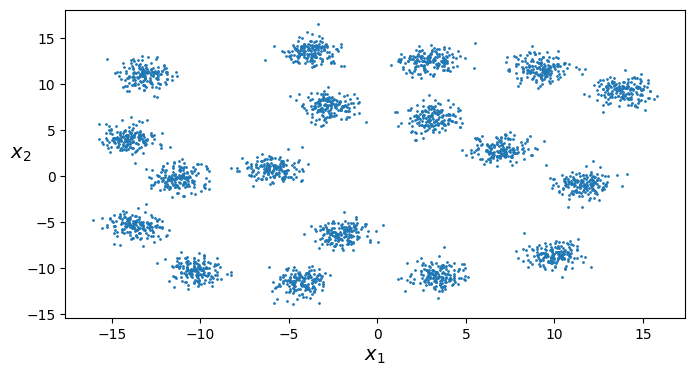

In [20]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

En *Scikit-Learn* puedes usar el objeto [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), indicando el número de clusters deseado.  

In [31]:
from sklearn.cluster import KMeans

# Usamos k_sintetico (número real de clusters generados)
k_sintetico = len(blob_centers)
kmeans = KMeans(n_clusters=k_sintetico, random_state=semilla)
y_pred = kmeans.fit_predict(X)

print(f"Clusters encontrados : {k_sintetico}")
y_pred

Clusters encontrados : 18


array([12,  8, 13, ...,  2, 11,  4], dtype=int32)

In [32]:
kmeans.cluster_centers_

array([[  9.95348124,  -8.55705765],
       [-14.02831661,   4.09773873],
       [  2.90818932,  12.52460512],
       [ -4.31803597, -11.50307721],
       [  5.04106847,   4.5926357 ],
       [ -5.92402577,   0.79970455],
       [ 13.87292829,   9.3142125 ],
       [  3.13359903, -11.50402903],
       [-13.67280181,  -5.36817328],
       [ -2.71145792,   7.62651217],
       [-13.14598972,  11.0179173 ],
       [ 11.58874822,  -0.8256688 ],
       [ -3.76546853,  13.54839974],
       [-10.29293308, -10.2271977 ],
       [ -2.043429  ,  -6.2501374 ],
       [-11.24383242,  -0.19211194],
       [  9.19278452,  11.7548528 ],
       [  3.59588117, -10.2571202 ]])

In [33]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 4, 5, 5], dtype=int32)

In [34]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

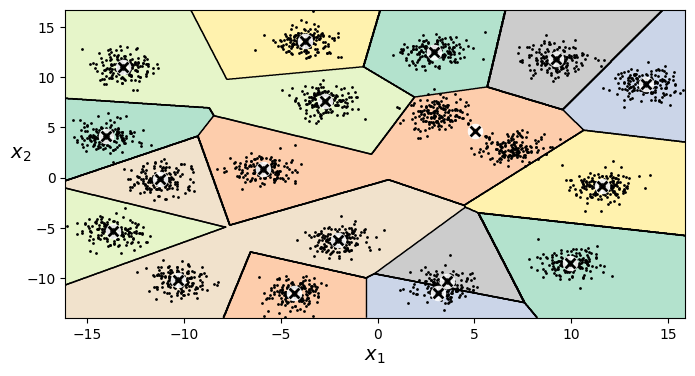

In [35]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()


En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [36]:
kmeans.transform(X_new)

array([[14.50941953, 14.18429324, 10.91901452, 14.17668963,  5.66869749,
         6.04440158, 15.68297943, 13.86283676, 15.53175737,  6.24577003,
        15.94176521, 11.92826431, 12.14678104, 15.98276681,  8.49943347,
        11.45552802, 13.40389646, 12.77369786],
       [12.64129612, 17.15704154, 10.52500556, 15.3586049 ,  3.29965459,
         9.00438477, 13.10413194, 13.50468988, 18.22833777,  8.01738055,
        18.49366963,  9.04162597, 13.38421088, 18.06118582,  9.66958858,
        14.41152722, 11.55455466, 12.27159607],
       [17.35967332, 11.08281542, 11.20824713, 14.56284544,  8.19727214,
         3.65940252, 18.01568729, 15.74763142, 13.56226466,  4.63550121,
        12.93167063, 15.08201964, 10.57613725, 15.10449045,  9.29946611,
         8.84026875, 15.01037781, 14.80732537],
       [17.03088959, 11.14345262, 11.63612516, 14.06497032,  8.30890524,
         3.38244458, 18.19695581, 15.28835721, 13.25959461,  5.13462595,
        13.24749118, 14.96300931, 11.07488505, 14.668

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [40]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k_sintetico, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k_sintetico, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k_sintetico, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=18, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=18, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=18, n_init=1, random_state=5)


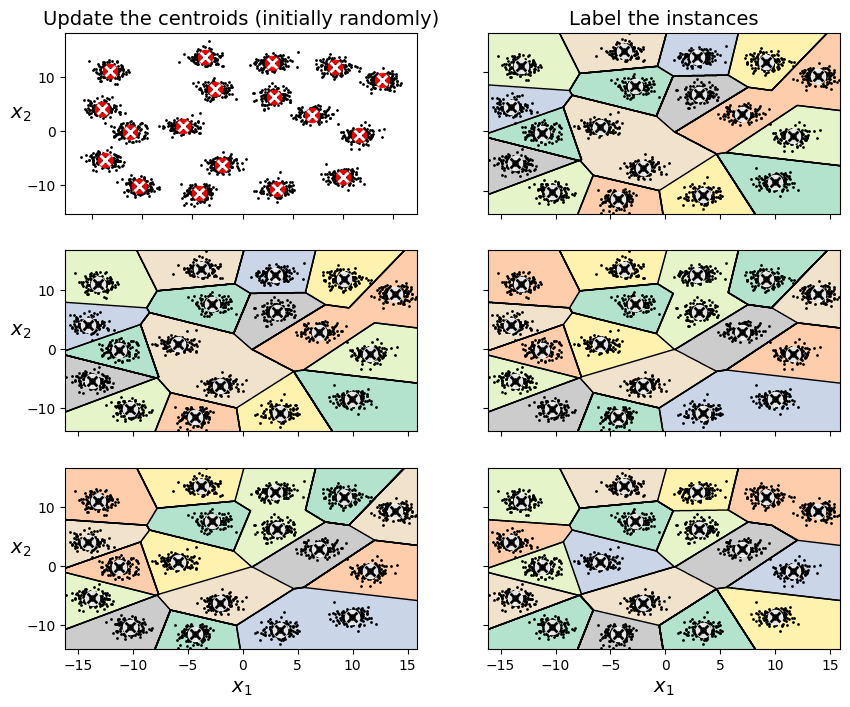

In [41]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

In [42]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

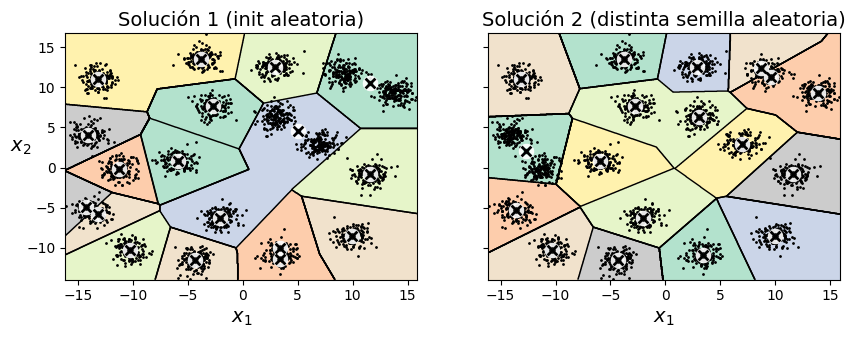

In [45]:
# Comparación: inicialización aleatoria y K-Means++
kmeans_rnd_init1 = KMeans(n_clusters=k_sintetico, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k_sintetico, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solución 1 (init aleatoria)",
                          "Solución 2 (distinta semilla aleatoria)")
plt.show()

Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

In [46]:
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)

KMeans(algorithm='elkan', init='random', n_clusters=5, n_init=10,
       random_state=11)

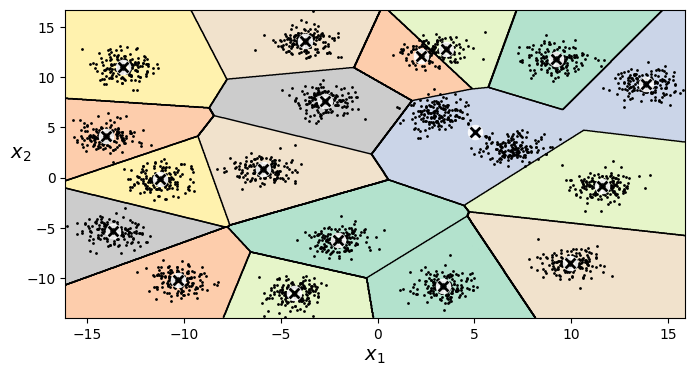

In [48]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Otras mejoras al algoritmo de *K-Means* incluyen: *K-Means* acelerados (usado por *Scikit-Learn* por defecto y que evita algunos cálculos de distancias) y *mini-batch K-Means* (que puedes usarse si el dataset es tan grande que no cabe en memoria). Vamos a ver un ejemplo de este último caso con el dataset MNIST, para lo cual usaremos el objeto [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html?highlight=minibatchkmeans#sklearn.cluster.MiniBatchKMeans).

In [49]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [50]:
from sklearn.cluster import MiniBatchKMeans

# k_minibatch es independiente de k_sintetico
k_minibatch = 5
n_init_mb = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init_mb):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k_minibatch, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

print(f"Mejor MiniBatchKMeans encontrado con k={k_minibatch}")

Mejor MiniBatchKMeans encontrado con k=5


In [51]:
best_kmeans.score(X)

-81671.39776210615

El algoritmo de *mini-batch K-Means* es más rápido que *K-Means* normal, pero su precisión suele ser peor.

### Encontrando el número óptimo de grupos

Como hemos visto anteriormente, el número de grupos o *clusters* es un hyperparámetro del modelo que debemos definir, y como podrás imaginar si nuestros datos no están etiquetados no será imposible saber qué valor usar. Para ello la solución se basa en usar diferentes valores y utilizar alguna métrica significativa. Una de estas métricas se conoce como el *silhouette score*, que se basa en calcular el coeficiente de silueta (*silhouette coefficient*) de todas las muestras del dataset como $(b-a)/\mathrm{max}(a,b)$ donde $a$ es la distancia mínima al resto de muestras del mismo grupo y $b$ es la distancia media de los grupos más cercanos. Su valor se encuentra entre $1$ y $-1$. Un valor cercano a $1$ indica que la muestra está bien metida en su grupo y lejos de los demás mientras que un valor cercano a $0$ indica que la muestra se encuentra cerca de una frontera de decisión y un valor cercano a $-1$ indica que la muestra está en el grupo incorrecto.

In [52]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.6855304875872903)

Calculando la métrica para diferentes números de *clusters* podemos encontrar el valor óptimo.

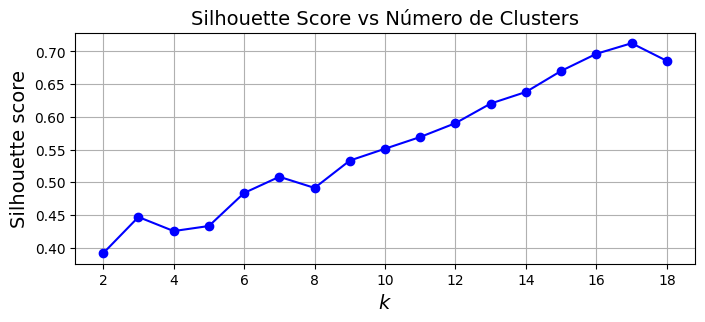

In [54]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()


## ELBOW METHOD

Calcula la inercia para distintos valores de k

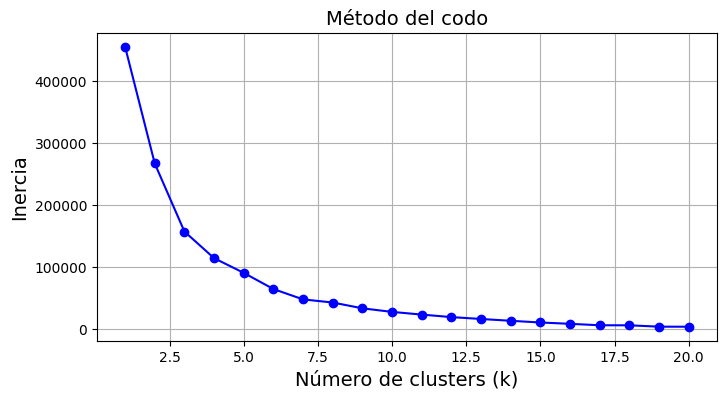

In [58]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

También es muy útil visualizar los diagramas de silueta, en el que visualizaremos todos los coeficientes de silueta ordenados por grupos y su valor.

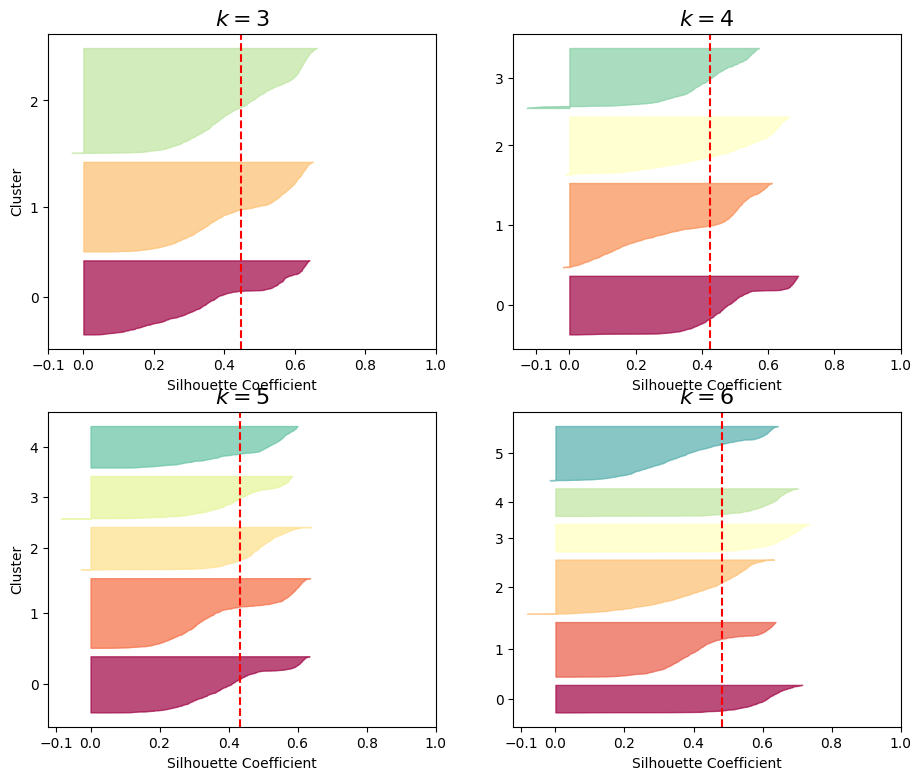

In [55]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

# for k in (3, 4, 5, 6):
#     plt.subplot(2, 2, k - 2)

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (3, 4, 5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

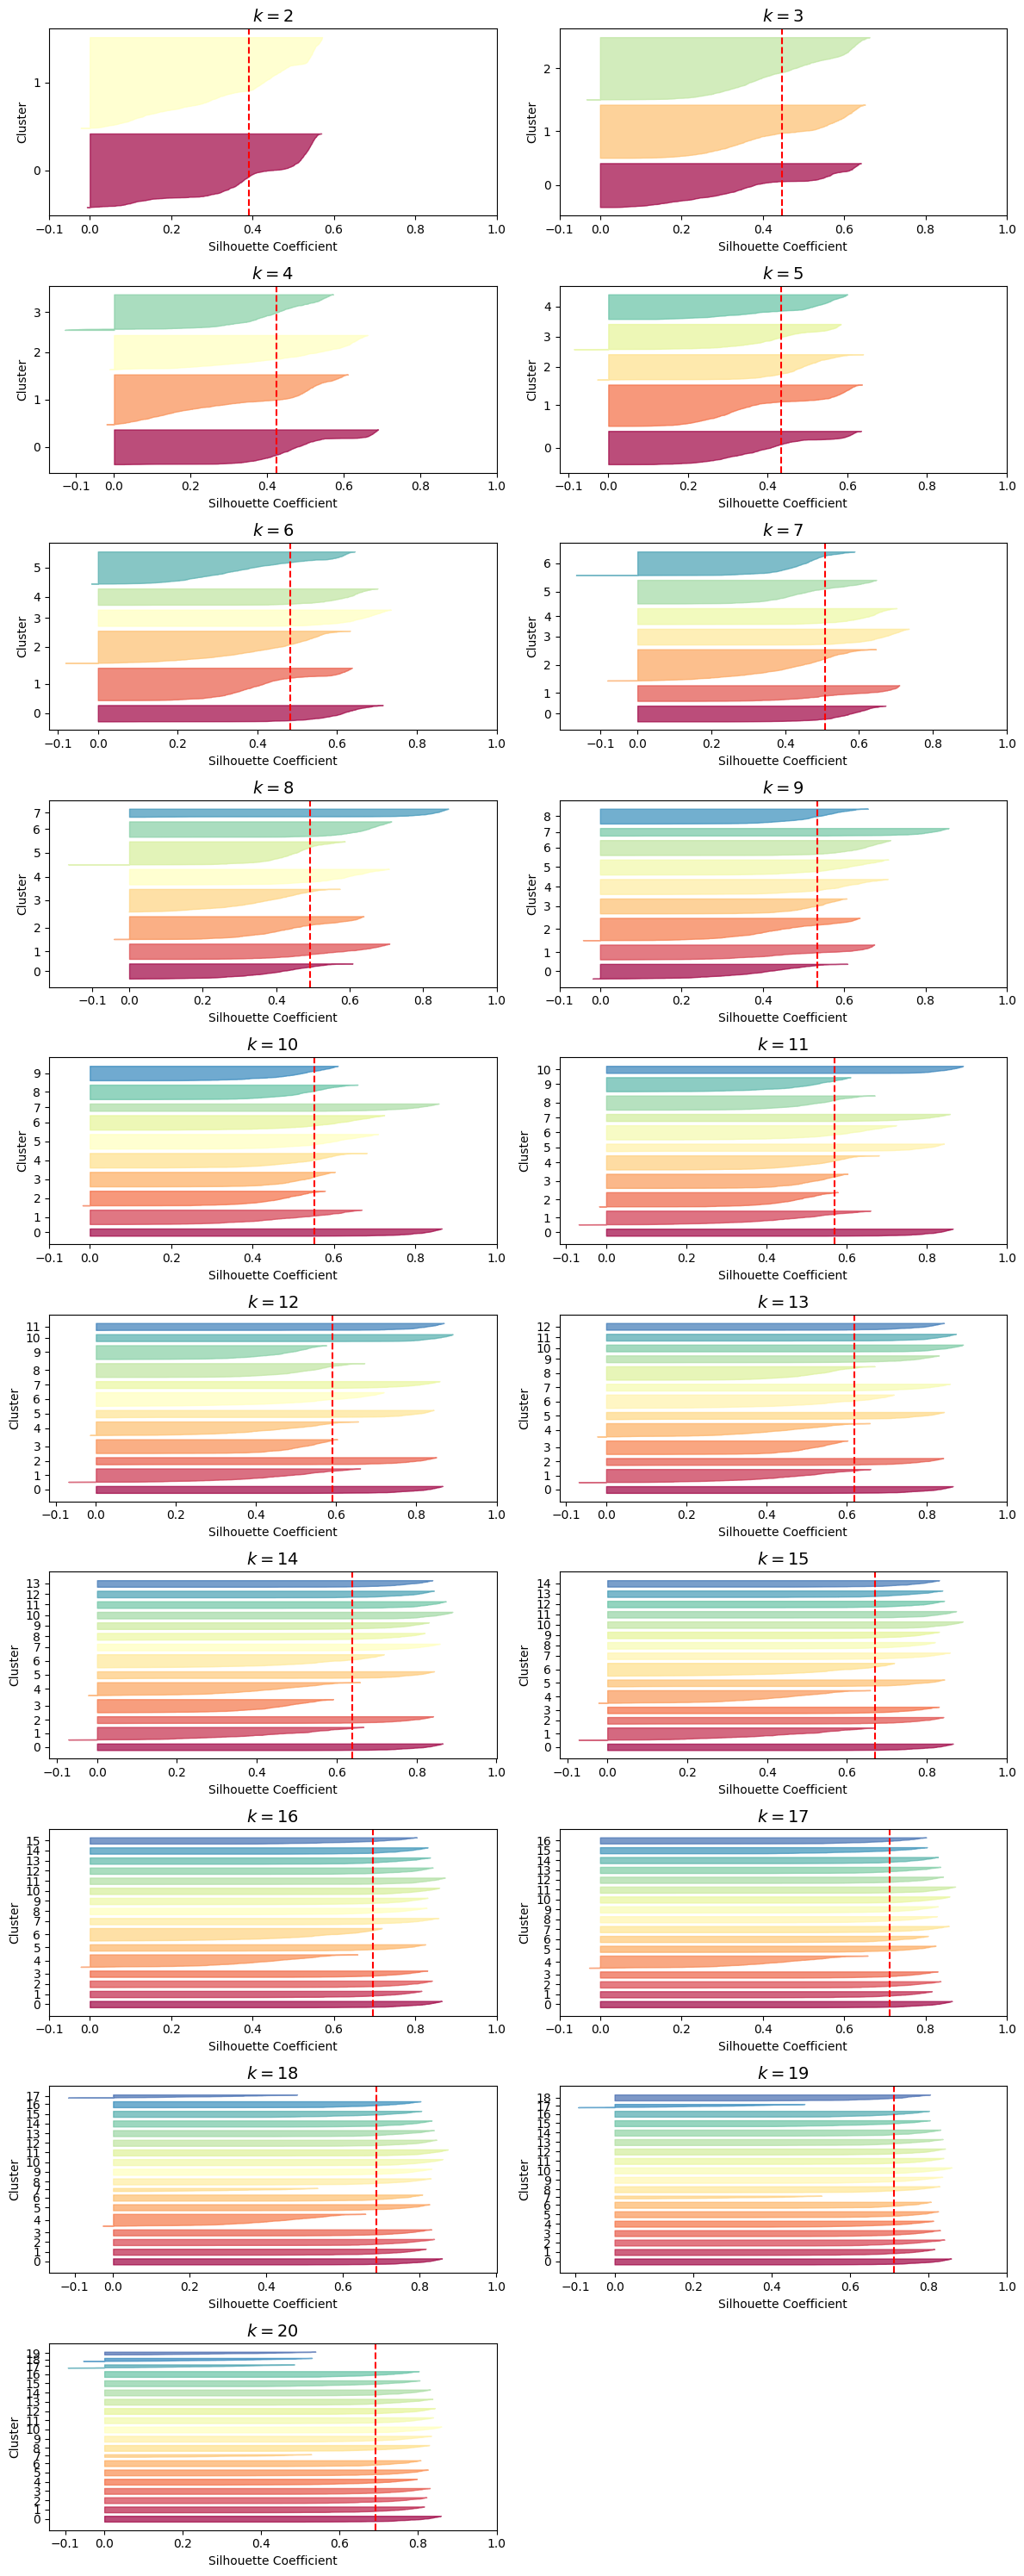

In [62]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

### K-Means para aprendizaje semi-supervisado.

El aprendizaje semi-supervisado, también conocido como Semi-supervised Learning, reúne técnicas que nos ayudan a entrenar modelos cuando solo tenemos una parte de los datos etiquetados. En esta sección veremos, de forma práctica y sencilla, cómo aplicar este enfoque usando el dataset bloodMNIST y el algoritmo K-Means. Para comenzar, cargamos el dataset y prepararemos los datos.

Rgb cuantos cuantos gb necesito para procesar, son calculos con la resolucion de las imagenes, que es bachear de kmeans

ecualizacion histograma, para que se usa la regresion logistica cuando,
primer modelo se entrena con las mas representativas

imagen 2d con rgb aplanar?

256

3*8 = 24bits

dividir en entramiento y prueba 80,20


